In [1]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from pytrends.request import TrendReq

### Set pytrend libary and keyword define

In [2]:
pytrends = TrendReq(hl= 'en-US' , tz=360)
keyword = 'Artificial Intelligence'

### Data Request

In [3]:
pytrends.build_payload([keyword] , cat = 0, timeframe= 'today 12-m' , geo='' , gprop='')

### Country wise interest

In [4]:
country_data = pytrends.interest_by_region()
country_data = country_data.sort_values(by = keyword , ascending=False).head(15)

C:\Users\HP\AppData\Local\Temp\ipykernel_11676\1521273545.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_data[keyword] , y=country_data.index, palette='Reds_d')


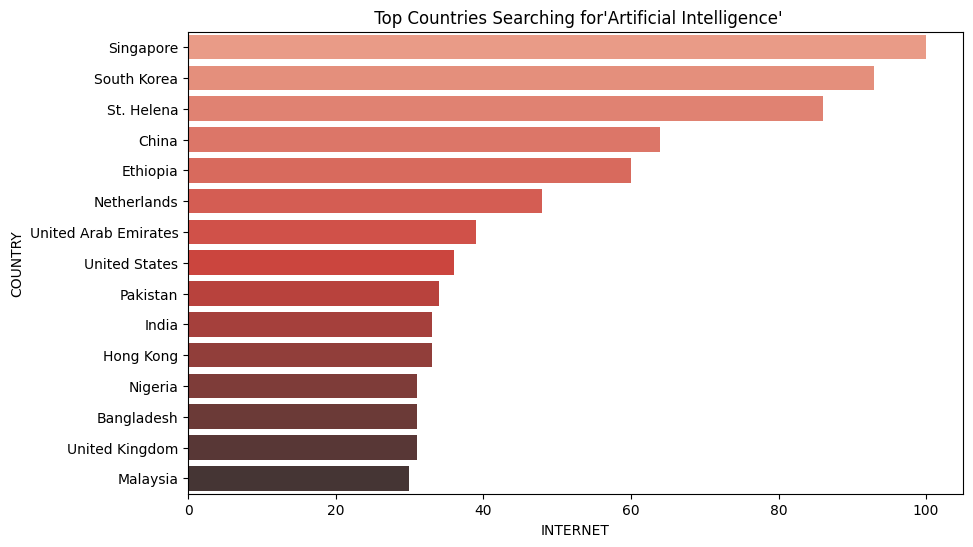

In [5]:
plt.figure(figsize=(10,6))
sns.barplot(x=country_data[keyword] , y=country_data.index, palette='Reds_d')
plt.title(f" Top Countries Searching for'{keyword}'")
plt.xlabel('INTERNET')
plt.ylabel('COUNTRY')
plt.show()

### Observation:
  There are top searching countries -<br>
    1. Singapore then<br>
    2. South Korea 

# World Map

In [6]:
country_data = country_data.reset_index()
fig = px.choropleth(country_data,
                    locations = 'geoName',
                    locationmode = 'country names',
                    color = keyword,
                    title = f"Search Interest for '{keyword}' by Country",
                    color_continuous_scale = 'Blues')

fig.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_11676\1188526803.py:2: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(country_data,


### Time wise Interest

In [7]:
time_df = pytrends.interest_over_time()

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytrends\request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


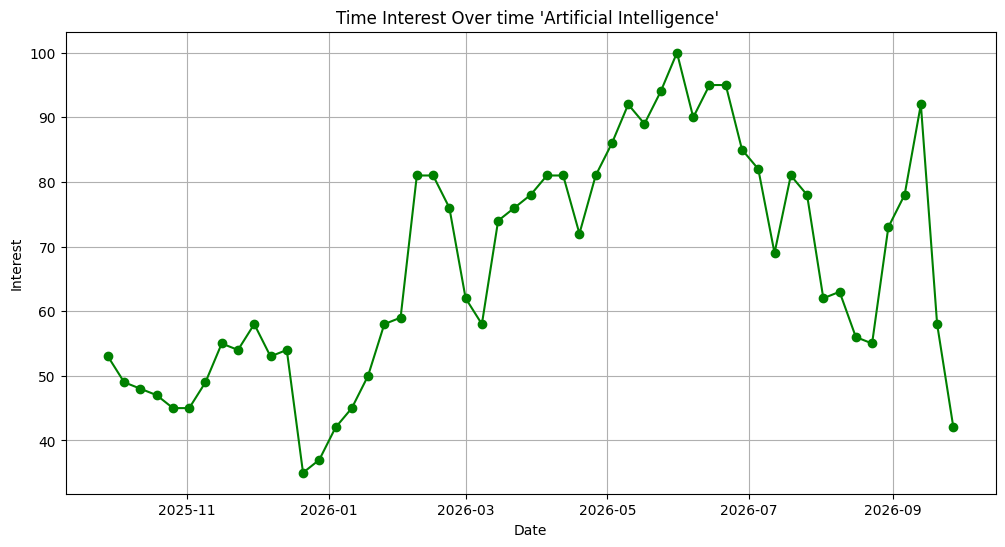

In [8]:
plt.figure(figsize=(12,6))
plt.plot(time_df.index , time_df[keyword] , marker = 'o' , color= 'green')
plt.title(f"Time Interest Over time '{keyword}' ")
plt.xlabel('Date')
plt.ylabel('Interest')
plt.grid(True)
plt.show()

### Observation:

1. **Overall Trend:** The search interest for 'Artificial Intelligence' grows significantly overall between late 2025 and mid-2026.
2. **Highest Peak:** Search popularity hits its maximum score of 100 around **June 2026**.
3. **Lowest Point:** The lowest search score (~35) occurs in **January 2026**.
4. **Recent Pattern:** After reaching its peak in June 2026, the search interest fluctuates and drops significantly by late September 2026.
5. **Data Markers:** Each green circle represents a specific data point over time.

# Multiple Keyword Compare

In [9]:
keyword_list = ['Artificial Intelligence','Cloud Computing','Data Science' , 'Machine Learning' , 'Deep learning']
pytrends.build_payload(keyword_list , cat=0, timeframe='today 12-m' , geo='', gprop='')

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytrends\request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


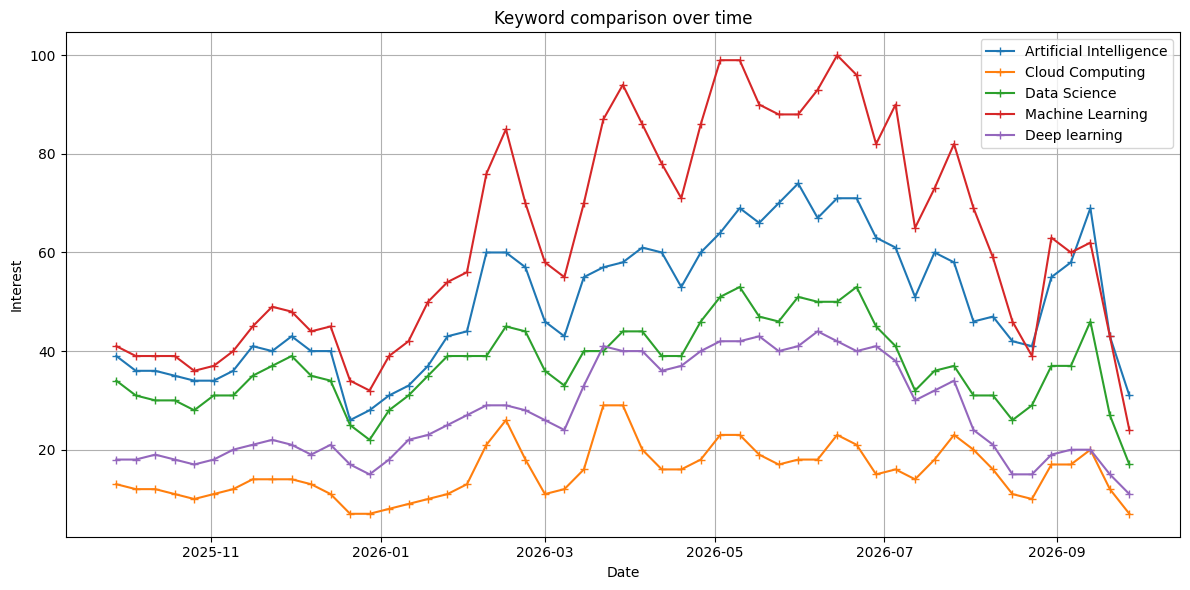

In [10]:
compare_df = pytrends.interest_over_time()

plt.figure(figsize=(12,6))
for kw in keyword_list:
  plt.plot(compare_df.index , compare_df[kw] , label = kw , marker='+')
plt.title('Keyword comparison over time')
plt.xlabel('Date')
plt.ylabel('Interest')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Observation:

1. **Highest Search Volume:** **Machine Learning (Red line)** remains the most searched keyword overall, reaching a peak interest score of 100 in mid-2026.
2. **Second Most Popular:** **Artificial Intelligence (Blue line)** maintains the second-highest search interest throughout the period, ranging between 26 and 74.
3. **Moderate Trends:** **Data Science (Green line)** and **Deep Learning (Purple line)** display moderate search activity, with Data Science generally staying slightly above Deep Learning.
4. **Lowest Interest:** **Cloud Computing (Orange line)** records the lowest search interest among all five keywords, staying mostly between 7 and 29.
5. **Key Peaks & Overall Patterns:** All keywords follow a similar trend pattern—experiencing a significant rise in interest between **March 2026 and June 2026**, followed by a sharp drop towards late September 2026.
6. **Data Markers:** The '+' markers along each line indicate the individual data points recorded over time.